# Машинное обучение. ВМК МГУ

# Практическое задание 6: Ансамбли

## Уровень: **Исследовательский (Research)**

# О формате сдачи

🔷 При решении ноутбука используйте данный шаблон

```
✅ Можно добавлять новые ячейки любых типов
❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий
```

🔷 При оценивании задач учитывается код

```
✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно
```

🔷 При оценивании задач учитываются выводы

```
✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
✅ Сопутствующие изображения, графики, таблички - приветствуются!
❌ При отсутствии выводов задание не засчитается на полный балл
```

В этом задании вы:

- Исследуете различные методы ансамблирования разных алгоритмов
- Поработаете с одним из самых мощных алгоритмов машинного обучения - Random Forest (случайными лесами)
- Порешаете интересную физическую задачку :)

**Примерное время выполнения (execution
time/время выполнения, если нажать run all) всех ячеек ноутбука при
правильной реализации: до 10 минут **

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, возможно, нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится

На скачивание файла и установку понадобится не более 5 минут.

**Важно!**

Устанавливать нужные версии нужно каждый раз, когда создается новый
рантайм. Например, если вы 2 часа подряд делаете это задание, то
подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в
понедельник, затем закрыли/выключили ноутбук, то при продолжении в
среду, вам нужно будет запустить рантайм заново и следовательно заново
установить библиотеки.

**Важно!**
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в соответствии с гайдом .pdf)

In [ ]:
# !!! Данный блок будет работать только в Google-Colab !!!
! gdown 10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
! pip install -r /content/requirements_2024_25_for_colab_small.txt

Downloading...
From: https://drive.google.com/uc?id=10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
To: /content/requirements_2024_25_for_colab_small.txt
100% 375/375 [00:00<00:00, 1.27MB/s]


Проверим версию библиотеки:

In [ ]:
import catboost
assert(catboost.__version__ == '1.2.7')

Теперь можно приступать к выполнению задания! :)

Привет, ребятушки!

Сегодняшний ноутбук посвящен методам ансамблирования.

**Ансамбли** - это техника, при
которой несколько моделей объединяются для получения более точных
результатов. Основная идея заключается в том, что объединение нескольких
"плохих" моделей может привести к получению одной, но очень хорошей
модели, ведь соответствующая теорема
обещает нам, что это возможно.
Существует несколько популярных подходов к ансамблированию. С базовыми
методами мы познакомимся в данном ноутбуке. А основному методу
ансамблирования, градиентному бустингу, будет посвящено отдельное
задание!

Внимание! При решении задач разрешается использовать n_jobs для ускорения обучения.

Импортируем необходимые библиотеки:

In [ ]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier

import matplotlib.pyplot as plt

#####
# если Вы не различаете предлагаемые цвета, то Вы можете раскомментить строку ниже
# для применения специальной цветовой палитры или аналогичных
# plt.style.use('tableau-colorblind10')
#####

import numpy as np

import time
import os

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Напишем функцию для генерации датасета и оценки модели. Для
экспериментов возьмем классический датасет по классификации рукописных
цифр. Чтобы сделать задачу более интересной поместим в обучающее
множество всего 10% от всего датасета.

In [ ]:
def get_dataset():
    """Return the splits of the dataset for training and testing"""
    X, y = load_digits(return_X_y=True)
    return train_test_split(X, y, random_state=42, train_size=0.1)

X_train, X_test, y_train, y_test = get_dataset()

def evaluate_model(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return acc

# Комитет большинства

Начнем знакомство с ансамблями с самого простого подхода - комитета большинства.

**Комитет большинства** — это
метод ансамблевого обучения, который объединяет предсказания нескольких
базовых моделей для улучшения общей производительности. Он работает по
принципу голосования: каждая из базовых моделей (например, деревья
решений, логистическая регрессия и т.д.) делает свои предсказания, а
комитет большинства агрегирует эти результаты.

Существует два основных типа голосования:

1. "hard voting" (жесткое голосование), где итоговый класс выбирается на основе большинства голосов,
2. "soft voting" (мягкое голосование), где учитываются вероятности
предсказаний моделей, и класс с наивысшей средней вероятностью
становится итоговым предсказанием.

Такой подход позволяет снизить вероятность ошибок, поскольку
объединение различных моделей может компенсировать слабости каждой из
них, что в конечном итоге приводит к более надежным и точным
предсказаниям.

## **Задание 1 [0.5 балла]**

Цели : В данном задании следует выполнить следующие пункты:

1. Создать отдельный LogisticRegression и оценить его точность с помощью функции evaluate_model , определенного выше.
2. Обучить модель VotingClassifier со следующими алгоритмами: LogisticRegression , KNeighborsClassifier и DecisionTreeClassifier в двух режимах:

- hard voting
- soft voting

1. Сравните качество на тесте всех трех классификаторов. Сделайте вывод о пользе комитета большинства.

**Примечание** - везде берите дефолтные параметры классов, кроме явно обозначенных для перебора

In [ ]:
from sklearn.ensemble import VotingClassifier

logreg_model = LogisticRegression(max_iter=4000)
knbrs_model = KNeighborsClassifier()
dscn_model = DecisionTreeClassifier()
print(f"LogisticRegression даёт результат {evaluate_model(logreg_model)}")
print(f"KNeighborsClassifier даёт результат {evaluate_model(knbrs_model)}")
print(f"DecisionTreeClassifier даёт результат {evaluate_model(dscn_model)}")


vclsfr_soft = VotingClassifier(estimators=[('lr', logreg_model), ('kn', knbrs_model), ('ds', dscn_model)], voting='soft')
vclsfr_hard = VotingClassifier(estimators=[('lr', logreg_model), ('kn', knbrs_model), ('ds', dscn_model)], voting='hard')
print(f"VotingClassifier в режиме soft даёт результат {evaluate_model(vclsfr_soft)}")
print(f"VotingClassifier в режиме hard даёт результат {evaluate_model(vclsfr_hard)}")

LogisticRegression даёт результат 0.9159456118665018
KNeighborsClassifier даёт результат 0.911619283065513
DecisionTreeClassifier даёт результат 0.6594561186650185
VotingClassifier в режиме soft даёт результат 0.9122373300370828
VotingClassifier в режиме hard даёт результат 0.9128553770086527


**Ваши выводы тут:**
В целом использование ансамблевого метода не дало большого прироста в
качестве моделей. Возможно, это из наличия "слабой" модели дерева
решений, которая в чистом виде показывала гораздо более плохую точность,
нежели чем KNN и LogReg. Догадка подтверждается тем, что в случае
soft-voting качество становится ещё хуже, так как из-за плохой модели
сместились вероятности классов

# Бэггинг

**Бэггинг**
(bagging, или bootstrap aggregating) - это такой приём в машинном
обучении, когда берется куча одинаковых моделей, где каждая модель
обучалась на случайном подмножестве нашего датасета. В итоге, хоть
каждая модель может ошибаться по-своему, в среднем ошибки
компенсируются, и итоговая предсказательная способность получается
лучше, чем у каждой модели по отдельности.

## **Задание 2.1 [0.25 балла]**

Верно ли, что random forest является чисто бэггингоим над деревьями решений? Или нет? Обоснуйте свой выбор

**Ваши выводы тут:**
Нет. Он действительно основан на бэггинге, однако в дополнение к нему
случайным образом выбирает подмножество признаков в каждом узле, с целью
сделать деревья более независимыми

## **Задание 2.2 [0.5 балла]**

Цели : В данном задании следует выполнить следующие пункты:

1. Создать отдельный DecisionTreeClassifier и оценить его точность с помощью функции evaluate_model , определенного выше.
2. Взять класс BaggingClassifier , являющийся стандартным методом sklearn , и создать два классификатора:

- один с использованием DecisionTreeClassifier в качестве базового метода,
- второй с использованием LogisticRegression . В обоих случаях бэггинг должен содержать по 10 моделей. Оцените качество обеих моделей.

1. Возьмите стандартный классификатор RandomForestClassifier и оцените его качество.
2. Сравните качество всех четырех классификаторов. Сделайте вывод о пользе бэггинга.

**Примечание** - везде берите дефолтные параметры классов

In [ ]:
from sklearn.ensemble import RandomForestClassifier

logreg_model = LogisticRegression(max_iter=4000)
dscn_model = DecisionTreeClassifier()
rnd_fr = RandomForestClassifier()
print(f"LogisticRegression даёт результат {evaluate_model(logreg_model)}")
print(f"DecisionTreeClassifier даёт результат {evaluate_model(dscn_model)}")
print(f"RandomForestClassifier даёт результат {evaluate_model(rnd_fr)}")

bg_log = BaggingClassifier(estimator=logreg_model)
bg_ds = BaggingClassifier(estimator=dscn_model)

print(f"BaggingClassifier с LogisticRegression даёт результат {evaluate_model(bg_log)}")
print(f"BaggingClassifier с DecisionTreeClassifier даёт результат {evaluate_model(bg_ds)}")

LogisticRegression даёт результат 0.9159456118665018
DecisionTreeClassifier даёт результат 0.6724351050679852
RandomForestClassifier даёт результат 0.892459826946848
BaggingClassifier с LogisticRegression даёт результат 0.9227441285537701
BaggingClassifier с DecisionTreeClassifier даёт результат 0.7836835599505563


**Ваши выводы тут:** Бэггинг
улучшает производительность моделей, особенно для слабых
классификаторов, таких как решающее дерево, где он значительно снижает
переобучение. В то время как для более устойчивых моделей, как
логистическая регрессия, эффект бэггинга менее заметен, но всё же имеет
небольшое улучшение. Случайный лес показывает высокую эффективность,
конкурируя с бэггированными моделями, и является оптимальным выбором для
задач классификации.

## **Задание 2.3 [0.5 балла]**

Цели : Сравнение BaggingClassifier над деревьями и RandomForestClassifier по качеству на тесте в зависимости от числа выбранных базовых алгоритмов.

1. Обучите BaggingClassifier над деревьями и RandomForestClassifier , перебирая кол-во базовых алгоритмов. Сетка должна содержать хотя бы 10 значений и покрывать диапазон от 1 до 500 деревьев
2. Получите качество на тесте ( evaluate_model ) и
отобразите это графически в зависимости от числа базовых алгоритмов для
двух типой моделей. Важно это сделать на одном полотне.
3. Сравните полученные графики. Какие выводы можно сделать о каждом
алгоритме? Сранвите результаты двух типов моделей друг с другом.

**Примечание** - везде (кроме кол-ва базовых алгоритмов) берите дефолтные параметры классов

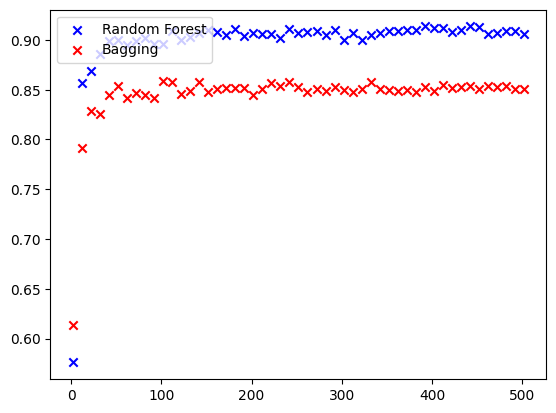

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

randf_res = [evaluate_model(RandomForestClassifier(n_estimators=i)) for i in range (2, 511, 10)]
bagg_res = [evaluate_model(BaggingClassifier(n_estimators=i)) for i in range (2, 511, 10)]

X = [i for i in range (2, 511, 10)]
Y = randf_res
Y1 = bagg_res
plt.scatter(X,Y, c='b', marker='x', label='Random Forest')
plt.scatter(X,Y1, c='r', marker='x', label='Bagging')
plt.legend(loc='upper left')
plt.show()

**Ваши выводы тут:**
Графики показывают, что основной прирост качества наблюдается при
увеличении количества деревьев от 1 до 100, затем обученые выходит на
плато, показывая только незначительные улучшения. При сравнении графиков
видно, что RandomForest в среднем демонстрирует качество выше, чем
BaggingClassifier, примерно на 0.1. Несмотря на это, тренды их поведения
очень схожи.

Как вы увидели в прошлом задании, использование случайного леса
помогает добиться качества выше, чем при использовании одного отдельного
дерева. Но что случится, если значительно увеличить число деревьев в
лесу? Приведет ли это к переобучению? Давайте проверим!

# Стэкинг

Следующий метод, с которым мы познакомимся - стэкинг.

**Стекинг** — это такая хитрая
стратегия ансамблирования, когда мы обучаем несколько различных методов
(как глупых, так и умных) и их предсказания подаются как признаки
какому-то другому методу, мета-классификатору. Этот мета-классификатор
обучается объединять предсказания всех методов и давать что-то более
верное. Давайте попробуем применить стэкинг, ведь он уже реализован за
нас!

## **Задание 3.1 [0.25 балла]**

Какая техника позволяет избежать утечки целевой переменной в стекинге? Коротко объясните

**Ваши выводы тут:** Чтобы избежать утечки целевой переменной в стекинге, используют Out-of-Fold (OOF) предсказания.
Суть метода :

Разбиваем train-данные на K фолдов.

Обучаем каждую базовую модель на K-1 фолдах и делаем предсказания на оставшемся фолде.

Повторяем процесс для всех фолдов.

mЭти предсказания используются для обучения метамодели (а не
предсказания на тех же данных, на которых обучались базовые модели).

## **Задание 3.2 [0.5 балла]**

Цели : В данном задании следует выполнить следующие пункты:

1. Использовать StackingClassifier из sklearn , создав ансамбль из двух базовых моделей: DecisionTreeClassifier и LogisticRegression . В качестве мета-модели используйте LogisticRegression . Оцените качество модели.
2. Добавить в стекинг ещё одну модель, например, RandomForestClassifier , и снова оценить качество предсказаний.
3. Сравните качество трёх классификаторов (отдельного дерева решений,
стекинга из двух моделей и стекинга из трёх моделей). Сделайте вывод о
пользе стекинга.

In [ ]:
print(f"Качество дерева решений {evaluate_model(DecisionTreeClassifier())}")
print(f"Качество логичстической регрессии {evaluate_model(LogisticRegression(max_iter=5000))}")

stck = StackingClassifier(estimators=[('ds', DecisionTreeClassifier()), ('lg', LogisticRegression(max_iter=5000))], final_estimator=LogisticRegression(max_iter=5000))
print(f"Качество стекинга из двух моделей {evaluate_model(stck)}")

stck2 = StackingClassifier(estimators=[('ds', DecisionTreeClassifier()), ('lg', LogisticRegression(max_iter=5000)), ('rdfr', RandomForestClassifier())], final_estimator=LogisticRegression(max_iter=5000))
print(f"Качество стекинга из трёх моделей {evaluate_model(stck2)}")

Качество дерева решений 0.6619283065512979
Качество логичстической регрессии 0.9159456118665018
Качество стекинга из двух моделей 0.9165636588380717
Качество стекинга из трёх моделей 0.9165636588380717


**Ваши выводы тут:**
Стэкинг сильно улучшил качество при сравнении его с чистой моделью
дерева решений. Случайный лес также внёс небольшую пользу в ансамбль, но
уже гораздо менее ощутимую

# Блэндинг

**Блендинг**
— это метод ансамблирования, похожий на стекинг, но с одной хитростью. В
нём используются две группы моделей: базовые модели, которые делают
предсказания, и мета-модель, которая учится комбинировать их результаты.
Главное отличие от стекинга в том, что базовые модели обучаются на
одном наборе данных, а мета-модель — на предсказаниях, сделанных на
отдельном валидационном наборе.

Таким образом, для реализации блендинга нужно разбить обучающее
множество на две части. На первой части обучить базовые модели, а на
второй - получить их предсказания и обучить мета-модель.

## **Задание 4 [1 балл]**

Цели : В данном задании следует выполнить следующие пункты:

1. Взять шаблон для BlendingClassifier , приведенный ниже, и заполнить все пропущенные участки кода.
2. Воспользоваться любыми базовыми моделями и попробовать получить лучшее качество на диком западе!

In [ ]:
import numpy.typing as npt
from typing import List, Tuple
from sklearn.base import BaseEstimator, ClassifierMixin


class BlendingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, base_models: List[ClassifierMixin], meta_model: ClassifierMixin,
                 valid_size: float = 0.2, random_state: int = 42) -> None:
        """
        :param base_models: список базовых моделей (не обученных)
        :param meta_model: мета-модель (не обученная)
        :param valid_size: доля данных для валидации (по умолчанию 20%)
        :param random_state: фиксированный seed для воспроизводимости
        """
        self.base_models: List[ClassifierMixin] = base_models
        self.meta_model: ClassifierMixin = meta_model
        self.valid_size: float = valid_size
        self.random_state: int = random_state
        self.fitted_base_models: List[ClassifierMixin] = []

    def _split_train_valid(self, X: npt.NDArray[np.float64],
                           y: npt.NDArray[np.int_]) -> Tuple[npt.NDArray[np.float64],
                                                              npt.NDArray[np.float64],
                                                              npt.NDArray[np.int_],
                                                              npt.NDArray[np.int_]]:
        """Разделяет данные на обучающую и валидационную выборки."""
        return train_test_split(X, y, test_size=self.valid_size, random_state=self.random_state)

    def _train_base_models(self, X_train: npt.NDArray[np.float64],
                           y_train: npt.NDArray[np.int_]) -> None:
        """Обучает базовые модели на обучающей выборке."""
        self.fitted_base_models = []
        for model in self.base_models:
            self.fitted_base_models.append(model.fit(X_train, y_train))

    def _generate_meta_features(self, X_valid: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
        """Создаёт новые фичи для мета-модели — предсказания базовых моделей."""
        X_mmod = []
        for model in self.fitted_base_models:
          X_mmod.append(model.predict(X_valid))
        return np.array(X_mmod).T

    def fit(self, X: npt.NDArray[np.float64], y: npt.NDArray[np.int_]) -> "BlendingClassifier":
        """Обучает базовые модели и затем мета-модель."""
        X_train, X_valid, y_train, y_valid = self._split_train_valid(X, y)

        # Обучение базовых моделей
        self._train_base_models(X_train, y_train)

        # Генерация мета-признаков
        X_metap = self._generate_meta_features(X_valid)

        # Обучение мета-модели
        self.meta_model.fit(X_metap, y_valid)

        return self.meta_model

    def predict(self, X: npt.NDArray[np.float64]) -> npt.NDArray[np.int_]:
        """Предсказывает класс на основе предсказаний базовых моделей."""

        X_base = []
        for model in self.base_models:
          X_base.append(model.predict(X))
        X_base = np.array(X_base).T
        return self.meta_model.predict(X_base)

classifier = BlendingClassifier([RandomForestClassifier(), RandomForestClassifier(), RandomForestClassifier(), RandomForestClassifier()], RandomForestClassifier())
evaluate_model(classifier)

0.9091470951792336


# ML-задача

С
этого момента мы изменим датасет и попытаемся поиграться с физикой:
возьмем коллекцию различных потенциалов и для них будем предсказывать
некоторую физическую величину. Обученные физики говорят, что эта
величина зависит от формы и глубины потенциала, а значит и мы можем тут
чему-то научиться. Ранее эту задачу пытались решить с помощью сверточных
нейронных сетей. А получится ли это у нас с помощью деревьев?

Загрузим датасет и посмотрим как он выглядит:

Внимание! Для выполнения этого задания вам понадобится публичный датасет из соответствующего ML-задания на cv-gml.ru.

Если вы выполняете задание в Google Colab , то можете пропустить дальнейший текст - данные скачаются в следующей ячейке кода.

Если вы делаете локально , то, пожалуйста, выполните эти пункты:

1. Скачайте архив Шаблон решения из ML-задания и разархивируйте его в любом удобном для вас месте.
2. Найдите переменную path_to_dataset , расположенную на первой строке ячейки после загрузки данных, и измените её значение на полный путь до папки [ПАПКА_ИЗВЛЕЧЕНИЯ]/public_tests/01_test_potentials_input/train/potentials

In [ ]:
!gdown 1l7bH623Jmdj-3pKSwhBgxlhkyZJ8xyCv

Downloading...
From (original): https://drive.google.com/uc?id=1l7bH623Jmdj-3pKSwhBgxlhkyZJ8xyCv
From (redirected): https://drive.google.com/uc?id=1l7bH623Jmdj-3pKSwhBgxlhkyZJ8xyCv&confirm=t&uuid=24e69117-77fd-432b-bcfe-f512c242b203
To: /content/trees_public_tests.zip
100% 27.8M/27.8M [00:00<00:00, 261MB/s]


Внимание! Если Вы выполняете
данное задание в google colab и предыдущий код выполнился с ошибкой
(файл не скачался), то Вам нужно будет скачать его вручную .

Для этого:

1. Перейдите по ссылке, указанной этом в сообщении об ошибке.
2. Скачайте файл вручную на локальный компьютер.
3. Нажмите на иконку папки в левой верхней части данного окна.
4. Вручную загрузите файл в корневую директорию (перетащив файл или нажав ПКМ -> загрузить).

In [ ]:
!unzip -d ./public_tests -u /content/trees_public_tests.zip

Archive:  /content/trees_public_tests.zip
   creating: ./public_tests/01_test_potentials_gt/
  inflating: ./public_tests/01_test_potentials_gt/target.json  
   creating: ./public_tests/01_test_potentials_input/
   creating: ./public_tests/01_test_potentials_input/train/
   creating: ./public_tests/01_test_potentials_input/train/potentials/
  inflating: ./public_tests/01_test_potentials_input/train/potentials/0a8c432fef7944bf9f56c5191d8074fe.npz  
  inflating: ./public_tests/01_test_potentials_input/train/potentials/0bc42452c94d493ab94e6d013cd9fecb.npz  
  inflating: ./public_tests/01_test_potentials_input/train/potentials/0fab6fb6c8b84f8da2d536a1fec73912.npz  
  inflating: ./public_tests/01_test_potentials_input/train/potentials/1a8739d04d024541a9b8ef7dc01d5611.npz  
  inflating: ./public_tests/01_test_potentials_input/train/potentials/1e98eec3244d4a4aaaa72ee02b74f028.npz  
  inflating: ./public_tests/01_test_potentials_input/train/potentials/0001f09663374722b1341b1e47f88d24.npz  
  in

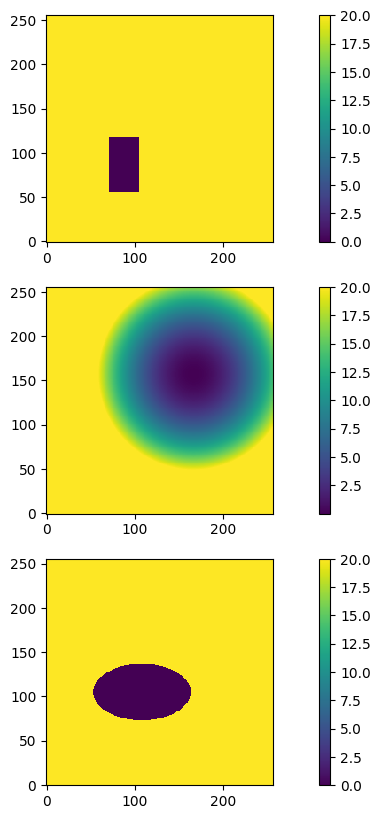

In [ ]:
path_to_dataset = "/content/public_tests/01_test_potentials_input/train/potentials"

chosen_ones = {'b2399918793e4228a3ea0a0a89adf11b.npz', '513d5523d14c47feb8b544138071c496.npz', 'ca9f96c404b740e3b28f583f9d9afbf8.npz'}

plt.figure(figsize=(12, 10))

def get_potential_dataset():

    global path_to_dataset

    """Return the training and testing splits of the potential dataset"""
    X, y = [], []

    plot_index = 1

    if not path_to_dataset.endswith("/"):
        path_to_dataset += "/"

    for f in os.listdir(path_to_dataset):

        npz = np.load(f'{path_to_dataset}{f}')
        data, target = npz['data'], npz['target']

        X.append(data)
        y.append(target)

        if f in chosen_ones:
            plt.subplot(len(chosen_ones), 1, plot_index)
            plt.imshow(data, origin="lower", interpolation='none')
            plt.colorbar()
            plot_index += 1
    plt.show()
    return train_test_split(np.array(X), np.array(y), random_state=42)

X_train, X_test, y_train, y_test = get_potential_dataset()

Можно увидеть, что у нас имеется три типа потенциалов: два с
бесконечно крутыми стенками: квадратный и эллиптический (их значение
резко меняется на 0). Также у нас имеется гармонический потенциал
(красивый и круглый, он плавно спускается к своему минимуму). В местах,
где потенциала нет, значение матрицы равно 20.

В глаза бросается одна проблема: матрицы у нас квадратные (каждая картинка 256 х 256 ),
а большинство методов машинного обучения работает с
векторами-признаками. К сожалению, нам придется с этим позже
разобраться. Но есть еще более крупная проблема: потенциалы находятся в
"случайных" местах рисунка, и оставлять это без внимания нельзя. Но
вернёмся к нашим баранам. У линейных регрессоров есть одно очень
полезное свойство: после обучения мы из коробки получаем
важность признаков: чем выше значение коэффициента (или абсолютное
значение) стоящего у признака, тем этот признак важнее. Деревья решений
не обладают столь же естественной оценкой важности
признаков, однако мы всё равно можем её получить. Называется эта оценка
критерием Джини: она вычисляет то, как начинают ошибаться
предсказания регрессора, если исключить данный признак. Чем сильнее
ошибка, тем важнее признак. К нашей радости, sklearn так же из коробки включает данные оценки признаков. Давайте попробуем воспользоваться этой функцией и посмотреть на важность признаков.

План наших действий следующий. Во-первых, мы должны преобразовать
квадратные матрицы в векторы. Для простоты воспользуемся обычным
reshape, что сможет гарантировать нам устойчивость преобразования.
Получив вектор, мы воспользуемся методами машинного обучения и получим
вектор, характеризующий важность каждого признака. Далее, с целью
визуализации этого вектора важностей и возможности его сопоставления с
оригинальными изображениями, воспользуемся обратным reshape в исходную
размерность. Reshape работает таким образом, что если мы сделаем всё
верно, то важности признаков попадут в те же пиксели, которым они
соответствуют в исходных изображениях. Давайте попробуем это!

## **Задание 5 [2 балла]**

Данные : потенциалы
Метрика качества : MAE
Цели : В данном задании следует выполнить следующие пункты:

1. Воспользоваться классом PotentialTransformer для преобразования двумерной матрицы в одномерный вектор
2. Воспользоваться классом Pipeline , чтобы "объединить" трансформатор и обучаемый метод
3. Обучить LinearSVR из sklearn на этом датасете.
4. Обучить RandomForestRegressor из sklearn на этом датасете.
5. Извлеките важность признаков из обученного леса с помощью feature_importances_ . Извлеките также коэффициенты svm через coef_ (брать абсолютные значения необязательно).
6. Преобразуйте одномерный вектор важностей признаков в двумерную
картинку таким образом, чтобы их можно было сравнивать с исходными
потенциалами. Постройте рисунки важностей признаков с помощью
plt.imshow. Добавьте легенду.
7. Оцените качество предсказаний через метод .predict.
8. Проанализируйте результаты. Можно ли сказать что у обоих методов
получились одинаковые важности признаков? Можно ли сказать, что важность
признаков отображает структуру потенциалов?

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVR
class PotentialTransformer:
    """
    A potential transformer.

    This class is used to convert the potential's 2d matrix to 1d vector of features.
    """

    def fit(self, x, y):
        """
        Build the transformer on the training set.
        :param x: list of potential's 2d matrices
        :param y: target values (can be ignored)
        :return: trained transformer
        """
        return self

    def fit_transform(self, x, y):
        """
        Build the transformer on the training set and return the transformed dataset (1d vectors).
        :param x: list of potential's 2d matrices
        :param y: target values (can be ignored)
        :return: transformed potentials (list of 1d vectors)
        """
        return self.transform(x)

    def transform(self, x):
        """
        Transform the list of potential's 2d matrices with the trained transformer.
        :param x: list of potential's 2d matrices
        :return: transformed potentials (list of 1d vectors)
        """
        return x.reshape((x.shape[0], -1))

# Your code here:

print(X_train_new := PotentialTransformer().transform(X_train))

pipelineLSVR = Pipeline([('transformer', PotentialTransformer()), ('regressor', LinearSVR())])
pipelineRF = Pipeline([('transformer', PotentialTransformer()), ('regressor', RandomForestRegressor())])

print(X_train.shape, y_train.shape)

pipelineLSVR.fit(X_train, y_train)
pipelineRF.fit(X_train, y_train)
tree_feature = pipelineRF['regressor'].feature_importances_.reshape(256, 256)
linear_feature = pipelineLSVR['regressor'].coef_.reshape(256, 256)

[[20. 20. 20. ... 20. 20. 20.]
 [20. 20. 20. ... 20. 20. 20.]
 [20. 20. 20. ... 20. 20. 20.]
 ...
 [20. 20. 20. ... 20. 20. 20.]
 [20. 20. 20. ... 20. 20. 20.]
 [20. 20. 20. ... 20. 20. 20.]]
(112, 256, 256) (112,)


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


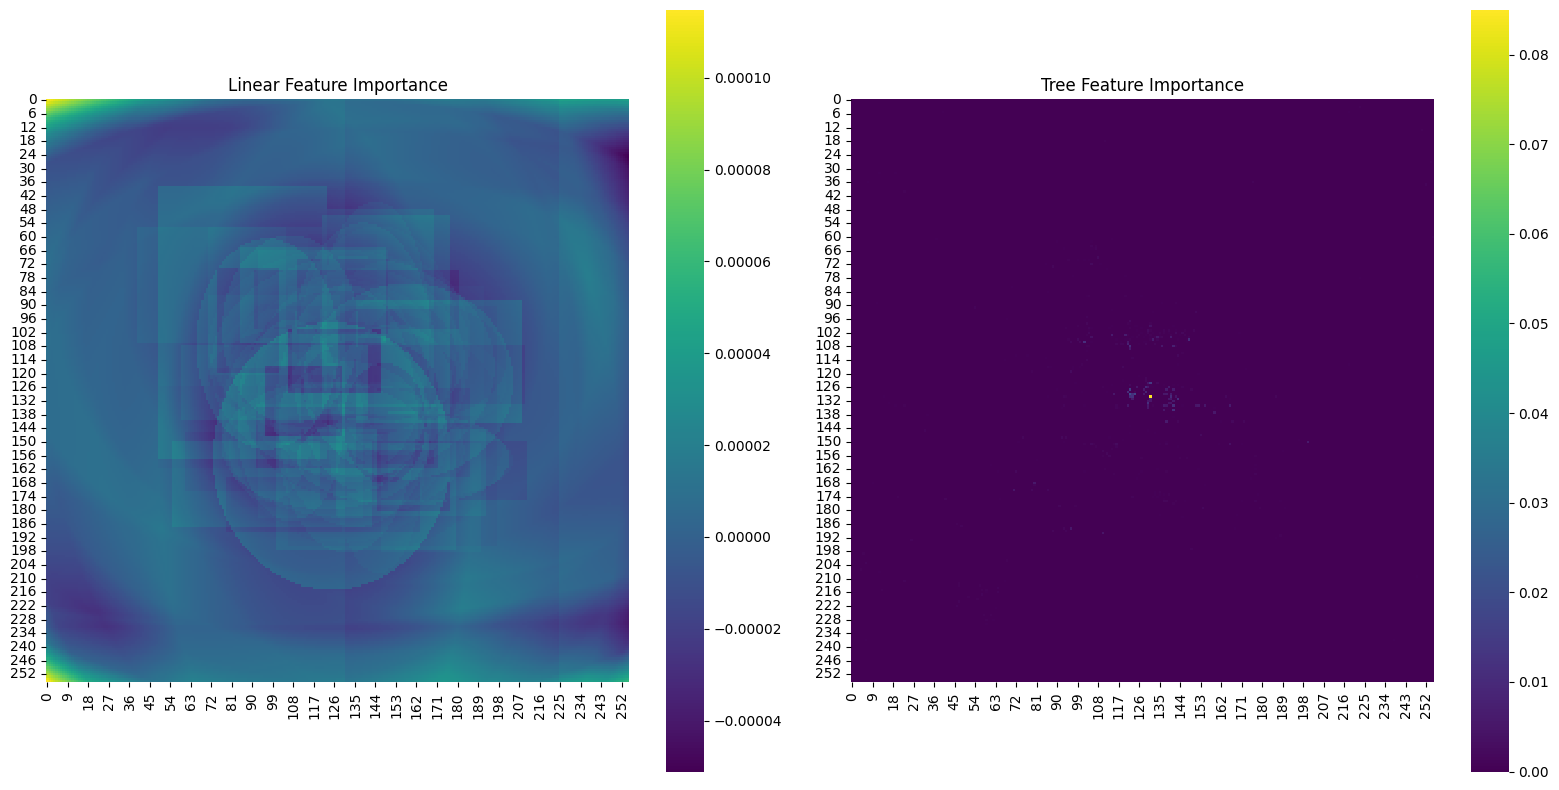

MAE for SVR: 0.0857714685576703
MAE for RF: 0.0405088719700781


In [ ]:
import seaborn as sns
from sklearn.metrics import mean_absolute_error


fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(linear_feature, ax=axes[0], cmap='viridis', cbar=True, square=True)
axes[0].set_title('Linear Feature Importance')

sns.heatmap(tree_feature, ax=axes[1], cmap='viridis', cbar=True, square=True)
axes[1].set_title('Tree Feature Importance')

plt.tight_layout()
plt.show()

y_pred_svr = pipelineLSVR.predict(X_test)
y_pred_rf = pipelineRF.predict(X_test)


print(f"MAE for SVR: {mean_absolute_error(y_test, y_pred_svr)}")
print(f"MAE for RF: {mean_absolute_error(y_test, y_pred_rf)}")

**Ваши выводы тут:** RandomForest показал лучшее качество, так как деревья решений лучше захватывают нелинейные зависимости в данных.

Если всё сделано верно, то в предыдущем задании вы должны были
увидеть некоторый сумбур в коэффициентах SVM. Можно увидеть, как
некоторые потенциалы "отпечатались" в признаках, т.е. метод явно
запомнил ответ, не пытаясь их обобщить. Видимо, нужно каким-то образом
"стандартизировать" потенциалы, чтобы было легче "обобщать" их. К
примеру, можно попробовать параллельно передвигать потенциал таким
образом, чтобы в центре всегда оказывалось минимальное значение (места
на матрице, не заполненные потенциалами, заполняются 20). Возможно вы
заметите и другие "проблемы" или найдёте более элегантные решения,
которые смогут помочь Вам улучшить результат.

Внимание! Следующее задание
проверяться на кросс-проверке НЕ БУДЕТ! Это решение нужно будет
загрузить в проверяющую систему в задание на ML-решение Здесь вы можете просто поиграть с данными и решением, подобрать оптимальные параметры на кросс-валидации

## **Задание 6 (ML-решение, сдается в систему)**

Данные : потенциалы
Метрика качества : MAE
Цели : в данном задании следует выполнить следующие пункты:

1. Улучшить метод PotentialTransformer , чтобы "стандартизировать" данные (к примеру, переносить потенциалы в одно и то же место изображения)
2. Воспользоваться классом Pipeline , чтобы "объединить" трансформатор и обучаемый метод
3. Обучить лучшие деревья на Диком Западе (можно воспользоваться любой реализацией лесов из sklearn).
4. Загрузить решение в тестирующую систему

Внимание! В этом задании разрешено пользоваться лишь любыми пройденными методами, кроме методов , являющихся или содержащих **градиентный бустинг** , а также любых **нейросетевых методов** !
Вы можете попробовать как и простые решения, так и пройденные в этом
семинаре методы ансамблирования. Например, со списком лесов, которые
реализованы в пакете sklearn.ensemble , можно ознакомиться тут . По описанию метода убедитесь, что бустинг в нём не применяется.

Внимание! В задании
на cv-gml.ru установлено ограничение по времени обучения в 10 минут.
Поэтому, если вы будете перебирать параметры по сетке, то такой перебор
может вполне занять несколько часов. Вы можете перебрать параметры в
данном ноутбуке, а в качестве решения уже отправить финальный вариант с
оптимальными найденными параметрами

Внимание! Если
будете использовать леса, то учтите, что время обучения леса зависит от
способности леса построить оптимальное разбиение! Если ваше обучение
проходит непозволительно долго, то, вероятно, лесам не удаётся подобрать
хорошее оптимальное разбиение, а значит, вам нужно подумать об ином
трансформаторе.

In [ ]:
import os

from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import ExtraTreesRegressor
from scipy import ndimage



import numpy as np


class PotentialTransformer:
    """
    A potential transformer.

    This class is used to convert the potential's 2d matrix to 1d vector of features.
    """

    def fit(self, x, y):
        """
        Build the transformer on the training set.
        :param x: list of potential's 2d matrices
        :param y: target values (can be ignored)
        :return: trained transformer
        """
        return self

    def fit_transform(self, x, y):
        """
        Build the transformer on the training set and return the transformed dataset (1d vectors).
        :param x: list of potential's 2d matrices
        :param y: target values (can be ignored)
        :return: transformed potentials (list of 1d vectors)
        """
        return self.transform(x)

    def transform(self, x):
        """
        Transform the list of potential's 2d matrices with the trained transformer.
        :param x: list of potential's 2d matrices
        :return: transformed potentials (list of 1d vectors)
        """
        centered_x = np.array([self.center_potential(matrix) for matrix in x])
        return centered_x.reshape((centered_x.shape[0], -1))
    def center_potential(self, x):
        mask = (x < 20).astype(float)
        sx, sy = x.shape[0]//2, x.shape[1]//2
        (cx, cy) = ndimage.center_of_mass(mask)
        shiftx, shifty  = int(sx - cx), int(sy - cy)
        x = np.roll(np.roll(x, shiftx, axis=0), shifty, axis=1)
        return x


def load_dataset(data_dir):
    """
    Read potential dataset.

    This function reads dataset stored in the folder and returns three lists
    :param data_dir: the path to the potential dataset
    :return    files -- the list of file names
    np.array(X) -- the list of potential matrices (in the same order as in files)
    np.array(Y) -- the list of target value (in the same order as in files)
    """
    files, X, Y = [], [], []
    for file in sorted(os.listdir(data_dir)):
        potential = np.load(os.path.join(data_dir, file))
        files.append(file)
        X.append(potential["data"])
        Y.append(potential["target"])
    return files, np.array(X), np.array(Y)


def train_model_and_predict(train_dir, test_dir):
    _, X_train, Y_train = load_dataset(train_dir)
    test_files, X_test, _ = load_dataset(test_dir)
    # it's suggested to modify only the following line of this function
    regressor = Pipeline([
        ('transformer', PotentialTransformer()),
        ('pca', TruncatedSVD(n_components=10)),
        ('decision_tree', ExtraTreesRegressor(n_estimators=900, criterion="friedman_mse", max_depth=20, n_jobs=-1))
    ])
    regressor.fit(X_train, Y_train)
    predictions = regressor.predict(X_test)

    return {file: value for file, value in zip(test_files, predictions)}

# **Задание 7 [Bonus][0.5 балл]**

Найдите мем про деревья решений/случайные леса лучше, чем этот:

Ну что, детишки. Поздравляю с еще одним выполненным ДЗ!